# EfficientNet Based LSTM Image Caption Generator

In [1]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
!git clone https://github.com/tylin/coco-caption.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-g63_2wjr
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-g63_2wjr
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=13a88d708d9eeae9665e1e99ec48f0ce1a2d1efd0af3b719469ae34f3947ae83
  Stored in directory: /tmp/pip-ephem-wheel-cache-_0ft3uez/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
Cloning into 'coco-caption'...
remote: Enumerating objects: 736, done.
remote: Total 736 (delta 0), reused 0 (delta 0), pack-reused 736 (from 1)
Receiving objects: 100% (736/736), 130.04 MiB | 16.44 MiB/s, done.
Resolving deltas: 100% (390/390), done.


In [2]:
import os
import json
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
import random
import re
import math
import torch
import clip
from PIL import Image
from tqdm import tqdm
import numpy as np
import sys
sys.path.append("coco-caption")
sys.path.append("coco-caption/pycocoevalcap")
sys.path.append("coco-caption/pycocoevalcap/cider")
from pycocoevalcap.cider.cider import Cider

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input as ef_preprocess
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, Callback

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flickr8k' dataset.
Path to dataset files: /kaggle/input/flickr8k


In [ ]:
print(path)
# /root/.cache/kagglehub/datasets/eeshawn/flickr30k/versions/1
# /kaggle/input/flickr8k

/kaggle/input/flickr8k


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()

100%|████████████████████████████████████████| 338M/338M [00:00<00:00, 368MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [6]:
DATA_DIR = path
IMAGES_DIR = os.path.join(DATA_DIR, "Images")
CAPTIONS_FILE = os.path.join(DATA_DIR, "captions.txt")


In [7]:
# Training hyperparameters
BATCH_SIZE = 64
EPOCHS = 30
EMBED_DIM = 300
LSTM_UNITS = 512
ATTN_UNITS = 512
MAX_VOCAB = 8000
MAX_LEN = 34  # maximum caption length (after tokenization)
TRAIN_VAL_SPLIT = 0.9

In [8]:
# Files for outputs & checkpoints
# BEST_MODEL_PATH = "best_model.h5"
CHECKPOINT_DIR = "/content/drive/MyDrive/Image Caption Generator"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "model_checkpoint.keras")
CSV_LOG_PATH = os.path.join(CHECKPOINT_DIR, "training_log.csv")
FEATURES_DIR = os.path.join(CHECKPOINT_DIR, "features") # Changed to a writable location
os.makedirs(FEATURES_DIR, exist_ok=True)
# EfficientNet input size
EFF_INPUT_SIZE = (300, 300)

In [9]:
def load_captions(captions_file):
    """
    Expect captions.txt lines like:
    image_name.jpg|A caption here.
    or
    image_name.jpg\tA caption here.
    """
    captions = {}
    with open(captions_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # try splitting by | or tab
            if "|" in line:
                img, cap = line.split("|", 1)
            elif "\t" in line:
                img, cap = line.split("\t", 1)
            elif " " in line:
                # fallback: first token is filename
                parts = line.split(" ", 1) # Split only on the first space
                if len(parts) > 1:
                    img, cap = parts[0], parts[1]
                else:
                    # If no space found, it might be an image name without a caption or malformed, skip it.
                    continue
            else:
                # If no clear separator, skip this line
                continue

            img = img.strip()
            cap = cap.strip()

            # Clean the image name to ensure it's just the filename (e.g., "12345.jpg")
            # This handles cases like "12345.jpg#0" or "12345.jpg,2,One" by extracting
            # the part that looks like a standard image filename.
            match = re.match(r"([\w-]+\.(?:jpg|jpeg|png))", img, re.IGNORECASE)
            if match:
                img = match.group(1)
            else:
                # If a valid image filename cannot be extracted, skip this entry
                continue

            captions.setdefault(img, []).append(cap)
    return captions

def clean_caption(c):
    # Lower, remove non-alpha punctuation except basic
    c = c.lower()
    c = re.sub(r"[^a-z0-9\s]", "", c)
    c = re.sub(r"\s+", " ", c).strip()
    return c

def prepare_captions_for_tokenizer(captions_dict):
    all_caps = []
    img_to_caps = {}
    for img, caps in captions_dict.items():
        cleaned = []
        for cap in caps:
            cc = clean_caption(cap)
            # add start/end tokens
            cc = "startseq " + cc + " endseq"
            cleaned.append(cc)
            all_caps.append(cc)
        img_to_caps[img] = cleaned
    return img_to_caps, all_caps

# -----------------------------
# Build tokenizer
# -----------------------------
def build_tokenizer(all_captions, max_words=MAX_VOCAB):
    tokenizer = Tokenizer(num_words=max_words, oov_token="unk")
    tokenizer.fit_on_texts(all_captions)
    # ensure startseq and endseq present
    return tokenizer

In [10]:
def build_feature_extractor():
  base = EfficientNetB3(weights="imagenet", include_top=False, input_shape=(EFF_INPUT_SIZE[0], EFF_INPUT_SIZE[1], 3))
  model = Model(inputs=base.input, outputs=base.output)
  return model

In [11]:
def extract_and_save_features(image_paths, feature_extractor, features_dir=FEATURES_DIR):
  """ Extracts spatial features and saves .npz per image with key 'feats' shape (num_patches, feat_dim) """
  for img_path in tqdm(image_paths, desc="Extracting features"):
    fname = os.path.basename(img_path)
    save_path = os.path.join(features_dir, fname + ".npz")
    if os.path.exists(save_path):
      continue
    # skip if already extracted # load image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=EFF_INPUT_SIZE)
    x = tf.keras.preprocessing.image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = ef_preprocess(x)
    feats = feature_extractor.predict(x) # shape (1, H, W, C)
    feats = feats[0] # (H, W, C)
    H, W, C = feats.shape
    feats = feats.reshape((H*W, C)) # (num_patches, feat_dim)
    np.savez_compressed(save_path, feats=feats)
  return

def load_image_feature_by_name(img_name, features_dir=FEATURES_DIR):
  file = os.path.join(features_dir, img_name + ".npz")
  if not os.path.exists(file):
    raise FileNotFoundError(f"Feature file not found: {file}")
  data = np.load(file)
  return data["feats"] # shape (num_patches, feat_dim)

# -----------------------------
# Keras Sequence generator
# -----------------------------
class CaptionSequence(tf.keras.utils.Sequence):
  # NEW: Changed features_dir to all_image_features
  def __init__(self, image_list, img_to_caps, tokenizer, max_len, batch_size, all_image_features, shuffle=True):
    self.image_list = image_list
    self.img_to_caps = img_to_caps
    self.tokenizer = tokenizer
    self.max_len = max_len
    self.batch_size = batch_size
    self.all_image_features = all_image_features # Store pre-loaded features
    self.shuffle = shuffle
    self.indexes = np.arange(len(self.image_list))
    self.on_epoch_end()

  def __len__(self):
    return math.ceil(len(self.image_list) / self.batch_size)

  def on_epoch_end(self):
    if self.shuffle:
      np.random.shuffle(self.indexes)

  def __getitem__(self, idx):
    batch_indexes = self.indexes[idx * self.batch_size:(idx + 1) * self.batch_size]
    batch_imgs = [self.image_list[i] for i in batch_indexes]

    # We'll construct X = [image_feats, input_seq] and y = target_seq (sparse)
    image_features_batch = []
    encoder_input_pads = []
    decoder_target_pads = []

    for img_name in batch_imgs:
      # NEW: Get features from in-memory dictionary
      feats = self.all_image_features[img_name]  # (num_patches, feat_dim)
      # pick a random caption for this image to increase data variety
      caps = self.img_to_caps[img_name]
      cap = random.choice(caps)
      seq = self.tokenizer.texts_to_sequences([cap])[0]  # list of ints including startseq/endseq

      # convert to input & target
      for i in range(1, len(seq)):
        in_seq = seq[:i]
        out_seq = seq[i]
        in_seq_padded = pad_sequences([in_seq], maxlen=self.max_len, padding="post")[0]
        image_features_batch.append(feats)  # (num_patches, feat_dim)
        encoder_input_pads.append(in_seq_padded)
        decoder_target_pads.append(out_seq)  # single token (int)
        # To limit memory for extremely long captions, we break if too many pairs per image:
        if len(encoder_input_pads) >= self.batch_size:
          break
    # optional: break if we already have full batch
    if len(encoder_input_pads) >= self.batch_size:
      pass

    # Now convert to numpy arrays
    # image_features_batch is list of arrays shape (num_patches, feat_dim). We convert to 3D array.
    # However images may have different patch dims? For EfficientNet with fixed input size they are same.
    image_features_batch = np.stack(image_features_batch, axis=0)  # (batch, num_patches, feat_dim)
    encoder_input_pads = np.array(encoder_input_pads, dtype="int32")  # (batch, max_len)
    decoder_target_pads = np.array(decoder_target_pads, dtype="int32")  # (batch, )

    # Targets should be categorical per-timestep. We'll use sparse_categorical_crossentropy on single-step target.
    return [image_features_batch, encoder_input_pads], decoder_target_pads

In [12]:
def build_caption_model(num_patches, feat_dim, vocab_size, max_len, embed_dim=EMBED_DIM,
                        lstm_units=LSTM_UNITS, attn_units=ATTN_UNITS):
    # Inputs
    img_feats_input = Input(shape=(num_patches, feat_dim), name="image_features")  # (batch, P, C)
    seq_input = Input(shape=(max_len,), name="seq_input")  # tokenized input sequence (post padding)

    # Project image features to a lower-dim space for attention
    img_feat_proj = layers.TimeDistributed(layers.Dense(attn_units, activation="tanh"))(img_feats_input)  # (batch, P, A)

    # sequence embedding + initial LSTM that returns sequences
    emb = layers.Embedding(vocab_size, embed_dim, mask_zero=False)(seq_input)  # (batch, T, E)
    decoder_seq = layers.LSTM(lstm_units, return_sequences=True)(emb)  # (batch, T, U)

    # Build a padding mask directly from seq_input (KerasTensor-safe)
    # mask_bool: (batch, T) boolean; then cast to float32 and expand -> (batch, T, 1)
    mask_float = layers.Lambda(lambda x: tf.cast(tf.not_equal(x, 0), tf.float32))(seq_input)
    mask_float = layers.Lambda(lambda m: tf.expand_dims(m, axis=-1))(mask_float)  # (batch, T, 1)

    # project decoder hidden states to attn_units
    dec_proj = layers.TimeDistributed(layers.Dense(attn_units, activation="tanh"))(decoder_seq)  # (batch, T, A)

    # Compute scores: batch matmul between dec_proj and img_feat_proj^T
    # dec_proj: (batch, T, A); img_feat_proj: (batch, P, A)
    # scores: (batch, T, P)
    scores = layers.Lambda(lambda x: tf.matmul(x[0], x[1], transpose_b=True))([dec_proj, img_feat_proj])

    # Apply mask to scores: expand mask to match scores shape for broadcasting
    # mask_float currently (batch, T, 1) -> broadcast to (batch, T, P) automatically when used in arithmetic
    large_neg = tf.constant(-1e9, dtype=tf.float32)
    masked_scores = layers.Lambda(lambda x: x[0] + (1.0 - x[1]) * large_neg)([scores, mask_float])

    # Softmax over patch dimension (P)
    attn_weights = layers.Softmax(axis=-1)(masked_scores)  # (batch, T, P)

    # Context vector: weighted sum of original image features (not projected) -> (batch, T, feat_dim)
    context = layers.Lambda(lambda x: tf.matmul(x[0], x[1]))([attn_weights, img_feats_input])  # (batch, T, C)

    # Combine context with decoder_seq (concatenate) and pass through TimeDistributed dense -> logits per timestep
    combined = layers.Concatenate(axis=-1)([context, decoder_seq])  # (batch, T, C+U)
    combined = layers.TimeDistributed(layers.Dense(512, activation="relu"))(combined)
    combined = layers.Dropout(0.25)(combined)
    outputs = layers.TimeDistributed(layers.Dense(vocab_size, activation="softmax"))(combined)  # (batch, T, V)

    model = Model(inputs=[img_feats_input, seq_input], outputs=outputs)
    return model


In [13]:
def prepare_data_and_tokenizer():
    captions = load_captions(CAPTIONS_FILE)
    img_to_caps, all_captions = prepare_captions_for_tokenizer(captions)
    tokenizer = build_tokenizer(all_captions, max_words=MAX_VOCAB)
    vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
    print(f"Vocabulary size: {vocab_size}, total images: {len(img_to_caps)}")
    return img_to_caps, tokenizer, vocab_size

# -----------------------------
# Utility to create sequence data suitable for model.fit
# Note: Our model outputs per-timestep softmax, so we build target sequences shaped (batch, T)
# and use sparse_categorical_crossentropy.
# -----------------------------
class FullSequenceGenerator(tf.keras.utils.Sequence):
    """
    Generates batches where X = [img_feats (batch, P, C), in_seqs (batch, T)]
                     y = out_seqs (batch, T, vocab_onehot) or sparse version (batch, T)
    We'll produce sparse integer targets and use sparse_categorical_crossentropy.
    """
    # NEW: Changed features_dir to all_image_features
    def __init__(self, image_list, img_to_caps, tokenizer, max_len, batch_size, all_image_features, shuffle=True):
        self.image_list = image_list
        self.img_to_caps = img_to_caps
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.batch_size = batch_size
        self.all_image_features = all_image_features # Store pre-loaded features
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.image_list))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.image_list) / self.batch_size)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, idx):
        batch_indexes = self.indexes[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_imgs = [self.image_list[i] for i in batch_indexes]

        image_features_batch = []
        encoder_in_batch = []
        decoder_out_batch = []

        for img_name in batch_imgs:
            # NEW: Get features from in-memory dictionary
            feats = self.all_image_features[img_name]  # (P, C)
            caps = self.img_to_caps[img_name]
            # use one random caption per image
            cap = random.choice(caps)
            seq = self.tokenizer.texts_to_sequences([cap])[0]
            # build full input/output sequence pair:
            # in_seq: [start, w1, w2, ..., wn-1, pad...], out_seq: [w1, w2, ..., wn, pad...]
            in_seq = seq[:-1]
            out_seq = seq[1:]
            in_seq_padded = pad_sequences([in_seq], maxlen=self.max_len, padding="post")[0]
            out_seq_padded = pad_sequences([out_seq], maxlen=self.max_len, padding="post")[0]
            image_features_batch.append(feats)
            encoder_in_batch.append(in_seq_padded)
            decoder_out_batch.append(out_seq_padded)

        image_features_batch = np.stack(image_features_batch, axis=0)  # (batch, P, C)
        encoder_in_batch = np.array(encoder_in_batch, dtype="int32")  # (batch, T)
        decoder_out_batch = np.array(decoder_out_batch, dtype="int32")  # (batch, T)

        # Change the list to a tuple for the model inputs
        return (image_features_batch, encoder_in_batch), decoder_out_batch

In [14]:
class TqdmEpochCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        msg = f"Epoch {epoch+1}: loss={logs.get('loss'):.4f}, acc={logs.get('sparse_categorical_accuracy'):.4f}, " \
              f"val_loss={logs.get('val_loss', float('nan')):.4f}, val_acc={logs.get('val_sparse_categorical_accuracy', float('nan')):.4f}"
        print(msg)


In [15]:
from tensorflow.keras.optimizers import Adam
def main():
    print("Preparing tokenizer and captions...")
    img_to_caps, tokenizer, vocab_size = prepare_data_and_tokenizer()

    # List of image filenames (keys in img_to_caps)
    all_images = list(img_to_caps.keys())
    random.shuffle(all_images)
    split = int(len(all_images) * TRAIN_VAL_SPLIT)
    train_images = all_images[:split]
    val_images = all_images[split:]
    print(f"Train images: {len(train_images)}, Val images: {len(val_images)}")

    # Build feature extractor and extract features if not present
    fe = build_feature_extractor()

    # Build full paths for image files (user may store images as just filenames; try to find path)
    image_paths = []
    for img_name in all_images:
        possible = os.path.join(IMAGES_DIR, img_name)
        if os.path.exists(possible):
            image_paths.append(possible)
        else:
            # try common extensions
            for ext in [".jpg", ".jpeg", ".png"]:
                p = os.path.join(IMAGES_DIR, img_name + ext)
                if os.path.exists(p):
                    image_paths.append(p)
                    break
            else:
                # This means the image was not found, which should ideally be handled earlier
                # or raised as an error if strict checking is needed.
                # For now, we'll just skip this image.
                print(f"Warning: Image not found for {img_name} in {IMAGES_DIR}. Skipping.")
                continue

    # Check if features are already extracted
    extracted_files = glob(os.path.join(FEATURES_DIR, "*.npz"))
    # Correctly count the number of image files in the directory
    num_expected_features = len(image_paths)

    if len(extracted_files) != num_expected_features:
        print(f"Expected {num_expected_features} feature files, found {len(extracted_files)}.\nExtracting features...")
        extract_and_save_features(image_paths, fe, FEATURES_DIR)
    else:
        print("Image features already extracted.")


    # For shape info: load one feature file to get (num_patches, feat_dim)
    sample_feat = all_image_features[all_images[0]] # Get from loaded features
    num_patches, feat_dim = sample_feat.shape
    print(f"Feature patch count: {num_patches}, feature dim: {feat_dim}")

    # Build model
    print("Building model...")
    model = build_caption_model(num_patches=num_patches, feat_dim=feat_dim,
                                vocab_size=vocab_size, max_len=MAX_LEN,
                                embed_dim=EMBED_DIM, lstm_units=LSTM_UNITS, attn_units=ATTN_UNITS)

    # Because model outputs full timestep predictions (batch, T, vocab), compile with sparse categorical crossentropy
    model.compile(optimizer=Adam(1e-4),
                  loss="sparse_categorical_crossentropy",
                  metrics=["sparse_categorical_accuracy"])

    # model.summary()

    # Prepare data generators (full-sequence)
    # NEW: Pass all_image_features to the generators
    train_gen = FullSequenceGenerator(train_images, img_to_caps, tokenizer, MAX_LEN, BATCH_SIZE, all_image_features, shuffle=True)
    val_gen = FullSequenceGenerator(val_images, img_to_caps, tokenizer, MAX_LEN, BATCH_SIZE, all_image_features, shuffle=False)

    # Callbacks: load existing checkpoint if present
    if os.path.exists(BEST_MODEL_PATH):
        try:
            print(f"Loading weights from existing checkpoint: {BEST_MODEL_PATH}")
            model.load_weights(BEST_MODEL_PATH)
        except Exception as e:
            print("Warning: could not load checkpoint:", e)

    # print(f"Loading weights from existing checkpoint: {BEST_MODEL_PATH}")
    # model.load_weights(BEST_MODEL_PATH)
    cb_checkpoint = ModelCheckpoint(BEST_MODEL_PATH, monitor="val_loss", save_best_only=True, verbose=1)
    cb_csv = CSVLogger(CSV_LOG_PATH, append=True)
    cb_tqdm = TqdmEpochCallback()

    print("Starting training...")
    history = model.fit(train_gen,
                        validation_data=val_gen,
                        epochs=10,
                        initial_epoch=40,
                        callbacks=[cb_checkpoint, cb_csv, cb_tqdm],
                        verbose=1)  # keep verbose for Keras progress bar

    # Save final model weights and tokenizer
    # final_weights = os.path.join(CHECKPOINT_DIR, "weights.keras")
    # model.save_weights(final_weights)
    # print("Saved final weights to:", final_weights)

    # Save tokenizer vocabulary and config
    with open(os.path.join(CHECKPOINT_DIR, "tokenizer.json"), "w", encoding="utf-8") as f:
        f.write(tokenizer.to_json())

    # Convert CSV log to a pandas df and print tail
    # df = pd.read_csv(CSV_LOG_PATH)
    # print("Last 5 epochs from CSV log:")
    # print(df.tail())


In [23]:
import os
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

def load_features_into_memory(image_names, features_dir):
    """
    Loads all image features into memory using a ThreadPoolExecutor for efficiency.
    """
    def load_single_feature(img_name):
        file_path = os.path.join(features_dir, img_name + ".npz")
        return img_name, np.load(file_path)

    print("Loading features into memory (fast mode)...")
    all_image_features_dict = {}
    with ThreadPoolExecutor(max_workers=16) as executor:
        for img_name, feat_data in tqdm(
            executor.map(load_single_feature, image_names),
            total=len(image_names),
            desc="Loading features"
        ):
            all_image_features_dict[img_name] = feat_data['feats'] # Assuming features are stored under 'feats' key

    print("Done. Features fully in RAM.")
    return all_image_features_dict


# Example usage (assuming img_to_caps and FEATURES_DIR are defined):
if 'img_to_caps' in globals() and 'FEATURES_DIR' in globals():
    all_image_names = list(img_to_caps.keys())
    all_image_features = load_features_into_memory(all_image_names, FEATURES_DIR)


Loading features into memory (fast mode)...


Loading features: 100%|██████████| 8091/8091 [07:22<00:00, 18.29it/s]

Done. Features fully in RAM.


This function `load_features_into_memory` takes a list of image names and the directory where features are stored, and returns a dictionary with image names as keys and their corresponding loaded features as values. It utilizes a `ThreadPoolExecutor` for parallel loading, which can significantly speed up the process.

In [ ]:
if __name__ == "__main__":
    main()

Preparing tokenizer and captions...
Vocabulary size: 8000, total images: 8091
Train images: 7281, Val images: 810
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Image features already extracted.


AttributeError: 'NpzFile' object has no attribute 'shape'

In [ ]:
if __name__ == "__main__":
    main()

Preparing tokenizer and captions...
Vocabulary size: 8000, total images: 8091
Train images: 7281, Val images: 810
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Expected 8091 feature files, found 0.
Extracting features...


Extracting features:   0%|          | 0/8091 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step


Extracting features:   0%|          | 1/8091 [00:20<45:21:40, 20.19s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


Extracting features:   3%|▎         | 243/8091 [00:56<20:07,  6.50it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Extracting features:   3%|▎         | 243/8091 [00:56<30:17,  4.32it/s]


KeyboardInterrupt: 

In [ ]:
if __name__ == "__main__":
    main()

Preparing tokenizer and captions...
Vocabulary size: 8000, total images: 8091
Train images: 7281, Val images: 810
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Extracting features:   0%|          | 0/8091 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


Extracting features:   0%|          | 1/8091 [00:18<42:29:40, 18.91s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


...

Extracting features: 100%|█████████▉| 8090/8091 [26:45<00:00,  5.11it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


Extracting features: 100%|██████████| 8091/8091 [26:46<00:00,  5.04it/s]


Feature patch count: 100, feature dim: 1536
Building model...


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.ops`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


In [ ]:
if __name__ == "__main__":
    main()

Preparing tokenizer and captions...
Vocabulary size: 8000, total images: 8091
Train images: 7281, Val images: 810
Feature patch count: 100, feature dim: 1536
Building model...


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 34, 300)   │  2,400,000 │ seq_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ (None, 34, 512)   │  1,665,024 │ embedding_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 100, 1536) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_33 │ (None, 34, 512)   │    262,656 │ lstm_9[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_32 │ (None, 100, 512)  │    786,944 │ image_features[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_22 (Lambda)  │ (None, 34)        │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_24 (Lambda)  │ (None, 34, 100)   │          0 │ time_distributed… │
│                     │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_23 (Lambda)  │ (None, 34, 1)     │          0 │ lambda_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_25 (Lambda)  │ (None, 34, 100)   │          0 │ lambda_24[0][0],  │
│                     │                   │            │ lambda_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_4 (Softmax) │ (None, 34, 100)   │          0 │ lambda_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_26 (Lambda)  │ (None, 34, 1536)  │          0 │ softmax_4[0][0],  │
│                     │                   │            │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_13      │ (None, 34, 2048)  │          0 │ lambda_26[0][0],  │
│ (Concatenate)       │                   │            │ lstm_9[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_34 │ (None, 34, 512)   │  1,049,088 │ concatenate_13[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 34, 512)   │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_35 │ (None, 34, 8000)  │  4,104,000 │ dropout_7[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,267,712 (39.17 MB)

 Trainable params: 10,267,712 (39.17 MB)

 Non-trainable params: 0 (0.00 B)

Loading weights from existing checkpoint: /content/drive/MyDrive/POM/model_checkpoint.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Starting training...
Epoch 2/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - loss: 1.6869 - sparse_categorical_accuracy: 0.7331Epoch 2: loss=1.6493, acc=0.7356, val_loss=1.5104, val_acc=0.7501
114/114 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - loss: 1.6865 - sparse_categorical_accuracy: 0.7331 - val_loss: 1.5104 - val_sparse_categorical_accuracy: 0.7501
Epoch 3/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - loss: 1.5034 - sparse_categorical_accuracy: 0.7501Epoch 3: loss=1.4693, acc=0.7539, val_loss=1.4087, val_acc=0.7620
114/114 ━━━━━━━━━━━━━━━━━━━━ 98s 860ms/step - loss: 1.5031 - sparse_categorical_accuracy: 0.7502 - val_loss: 1.4087 - val_sparse_categorical_accuracy: 0.7620
Epoch 4/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - loss: 1.3935 - sparse_categorical_accuracy: 0.7606Epoch 4: loss=1.3772, acc=0.7629, val_loss=1.3643, val_acc=0.7625
114/114 ━━━━━━━━━━━━━━━━━━━━ 94s 825ms/step - loss: 1.3934 - sparse_categorical_accuracy: 0.7606 - val_loss: 1.3643 - val_sparse_categorical_accuracy

In [ ]:
if __name__ == '__main__':
  main()

Preparing tokenizer and captions...
Vocabulary size: 8000, total images: 8091
Train images: 7281, Val images: 810
Feature patch count: 100, feature dim: 1536
Loading weights from existing checkpoint: /content/drive/MyDrive/POM/model_checkpoint.keras
Starting training...
Epoch 31/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - loss: 1.0019 - sparse_categorical_accuracy: 0.7991Epoch 31: loss=1.0108, acc=0.7979, val_loss=0.8880, val_acc=0.8158
114/114 ━━━━━━━━━━━━━━━━━━━━ 105s 845ms/step - loss: 1.0019 - sparse_categorical_accuracy: 0.7991 - val_loss: 0.8880 - val_sparse_categorical_accuracy: 0.8158
Epoch 32/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - loss: 1.0001 - sparse_categorical_accuracy: 0.7998Epoch 32: loss=1.0081, acc=0.7988, val_loss=0.9216, val_acc=0.8102
114/114 ━━━━━━━━━━━━━━━━━━━━ 93s 811ms/step - loss: 1.0001 - sparse_categorical_accuracy: 0.7998 - val_loss: 0.9216 - val_sparse_categorical_accuracy: 0.8102
Epoch 33/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - loss: 1

In [ ]:
if __name__ == '__main__':
  main()

Preparing tokenizer and captions...
Vocabulary size: 8000, total images: 8091
Train images: 7281, Val images: 810
Image features already extracted.
Loading all image features into memory...


Loading features: 100%|██████████| 8091/8091 [32:47<00:00,  4.11it/s]


All image features loaded.
Feature patch count: 100, feature dim: 1536
Building model...
Loading weights from existing checkpoint: /content/drive/MyDrive/POM/model_checkpoint.keras
Starting training...
Epoch 41/50


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.9052 - sparse_categorical_accuracy: 0.8112
Epoch 41: val_loss improved from inf to 0.83444, saving model to /content/drive/MyDrive/POM/model_checkpoint.keras
Epoch 41: loss=0.8949, acc=0.8131, val_loss=0.8344, val_acc=0.8219
114/114 ━━━━━━━━━━━━━━━━━━━━ 29s 178ms/step - loss: 0.9051 - sparse_categorical_accuracy: 0.8112 - val_loss: 0.8344 - val_sparse_categorical_accuracy: 0.8219
Epoch 42/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.8886 - sparse_categorical_accuracy: 0.8153
Epoch 42: val_loss improved from 0.83444 to 0.82524, saving model to /content/drive/MyDrive/POM/model_checkpoint.keras
Epoch 42: loss=0.8859, acc=0.8161, val_loss=0.8252, val_acc=0.8199
114/114 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - loss: 0.8886 - sparse_categorical_accuracy: 0.8153 - val_loss: 0.8252 - val_sparse_categorical_accuracy: 0.8199
Epoch 43/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.8846 - sparse_categorical_accuracy: 0.8153
Epoc

In [25]:
model = model.load_weights("/content/drive/MyDrive/Image Caption Generator/model.keras")

In [29]:
model

In [27]:
print(model.summary())

AttributeError: 'NoneType' object has no attribute 'summary'

In [20]:
extracted_files = glob(os.path.join(FEATURES_DIR, "*.npz"))
if len(extracted_files) != len(os.listdir(IMAGES_DIR)):
  print(f"Expected {len(IMAGES_DIR)} feature files, found {len(extracted_files)}.\nExtracting features...")
  # extract_and_save_features(IMAGES_DIR, fe, FEATURES_DIR)
else:
  print("Image features already extracted.")

Image features already extracted.


In [ ]:
print("Preparing tokenizer and captions...")
img_to_caps, tokenizer, vocab_size = prepare_data_and_tokenizer()

# List of image filenames (keys in img_to_caps)
all_images = list(img_to_caps.keys())
random.shuffle(all_images)
split = int(len(all_images) * TRAIN_VAL_SPLIT)
train_images = all_images[:split]
val_images = all_images[split:]
print(f"Train images: {len(train_images)}, Val images: {len(val_images)}")

# Build feature extractor and extract features if not present
fe = build_feature_extractor()

# Build full paths for image files (user may store images as just filenames; try to find path)
image_paths = []
for img_name in all_images:
    possible = os.path.join(IMAGES_DIR, img_name)
    if os.path.exists(possible):
        image_paths.append(possible)
    else:
        # try common extensions
        for ext in [".jpg", ".jpeg", ".png"]:
            p = os.path.join(IMAGES_DIR, img_name + ext)
            if os.path.exists(p):
                image_paths.append(p)
                break
        else:
            # This means the image was not found, which should ideally be handled earlier
            # or raised as an error if strict checking is needed.
            # For now, we'll just skip this image.
            print(f"Warning: Image not found for {img_name} in {IMAGES_DIR}. Skipping.")
            continue


# Build model
print("Building model...")
model = build_caption_model(num_patches=num_patches, feat_dim=feat_dim,
                            vocab_size=vocab_size, max_len=MAX_LEN,
                            embed_dim=EMBED_DIM, lstm_units=LSTM_UNITS, attn_units=ATTN_UNITS)

# Because model outputs full timestep predictions (batch, T, vocab), compile with sparse categorical crossentropy
model.compile(optimizer=Adam(1e-4),
              loss="sparse_categorical_crossentropy",
              metrics=["sparse_categorical_accuracy"])

# model.summary()

# Prepare data generators (full-sequence)
# NEW: Pass all_image_features to the generators
train_gen = FullSequenceGenerator(train_images, img_to_caps, tokenizer, MAX_LEN, BATCH_SIZE, all_image_features, shuffle=True)
val_gen = FullSequenceGenerator(val_images, img_to_caps, tokenizer, MAX_LEN, BATCH_SIZE, all_image_features, shuffle=False)

# Callbacks: load existing checkpoint if present
if os.path.exists(BEST_MODEL_PATH):
    try:
        print(f"Loading weights from existing checkpoint: {BEST_MODEL_PATH}")
        model.load_weights(BEST_MODEL_PATH)
    except Exception as e:
        print("Warning: could not load checkpoint:", e)

# print(f"Loading weights from existing checkpoint: {BEST_MODEL_PATH}")
# model.load_weights(BEST_MODEL_PATH)
cb_checkpoint = ModelCheckpoint(BEST_MODEL_PATH, monitor="val_loss", save_best_only=True, verbose=1)
cb_csv = CSVLogger(CSV_LOG_PATH, append=True)
cb_tqdm = TqdmEpochCallback()


Preparing tokenizer and captions...
Vocabulary size: 8000, total images: 8091
Train images: 7281, Val images: 810
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Image features already extracted.
Loading all image features into memory...


Loading features: 100%|██████████| 8091/8091 [13:48<00:00,  9.76it/s]


All image features loaded.
Feature patch count: 100, feature dim: 1536
Building model...
Loading weights from existing checkpoint: /content/drive/MyDrive/POM/model_checkpoint.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model = build_caption_model(num_patches=100, feat_dim=1536,
                                vocab_size=8000, max_len=MAX_LEN,
                                embed_dim=EMBED_DIM, lstm_units=LSTM_UNITS, attn_units=ATTN_UNITS)

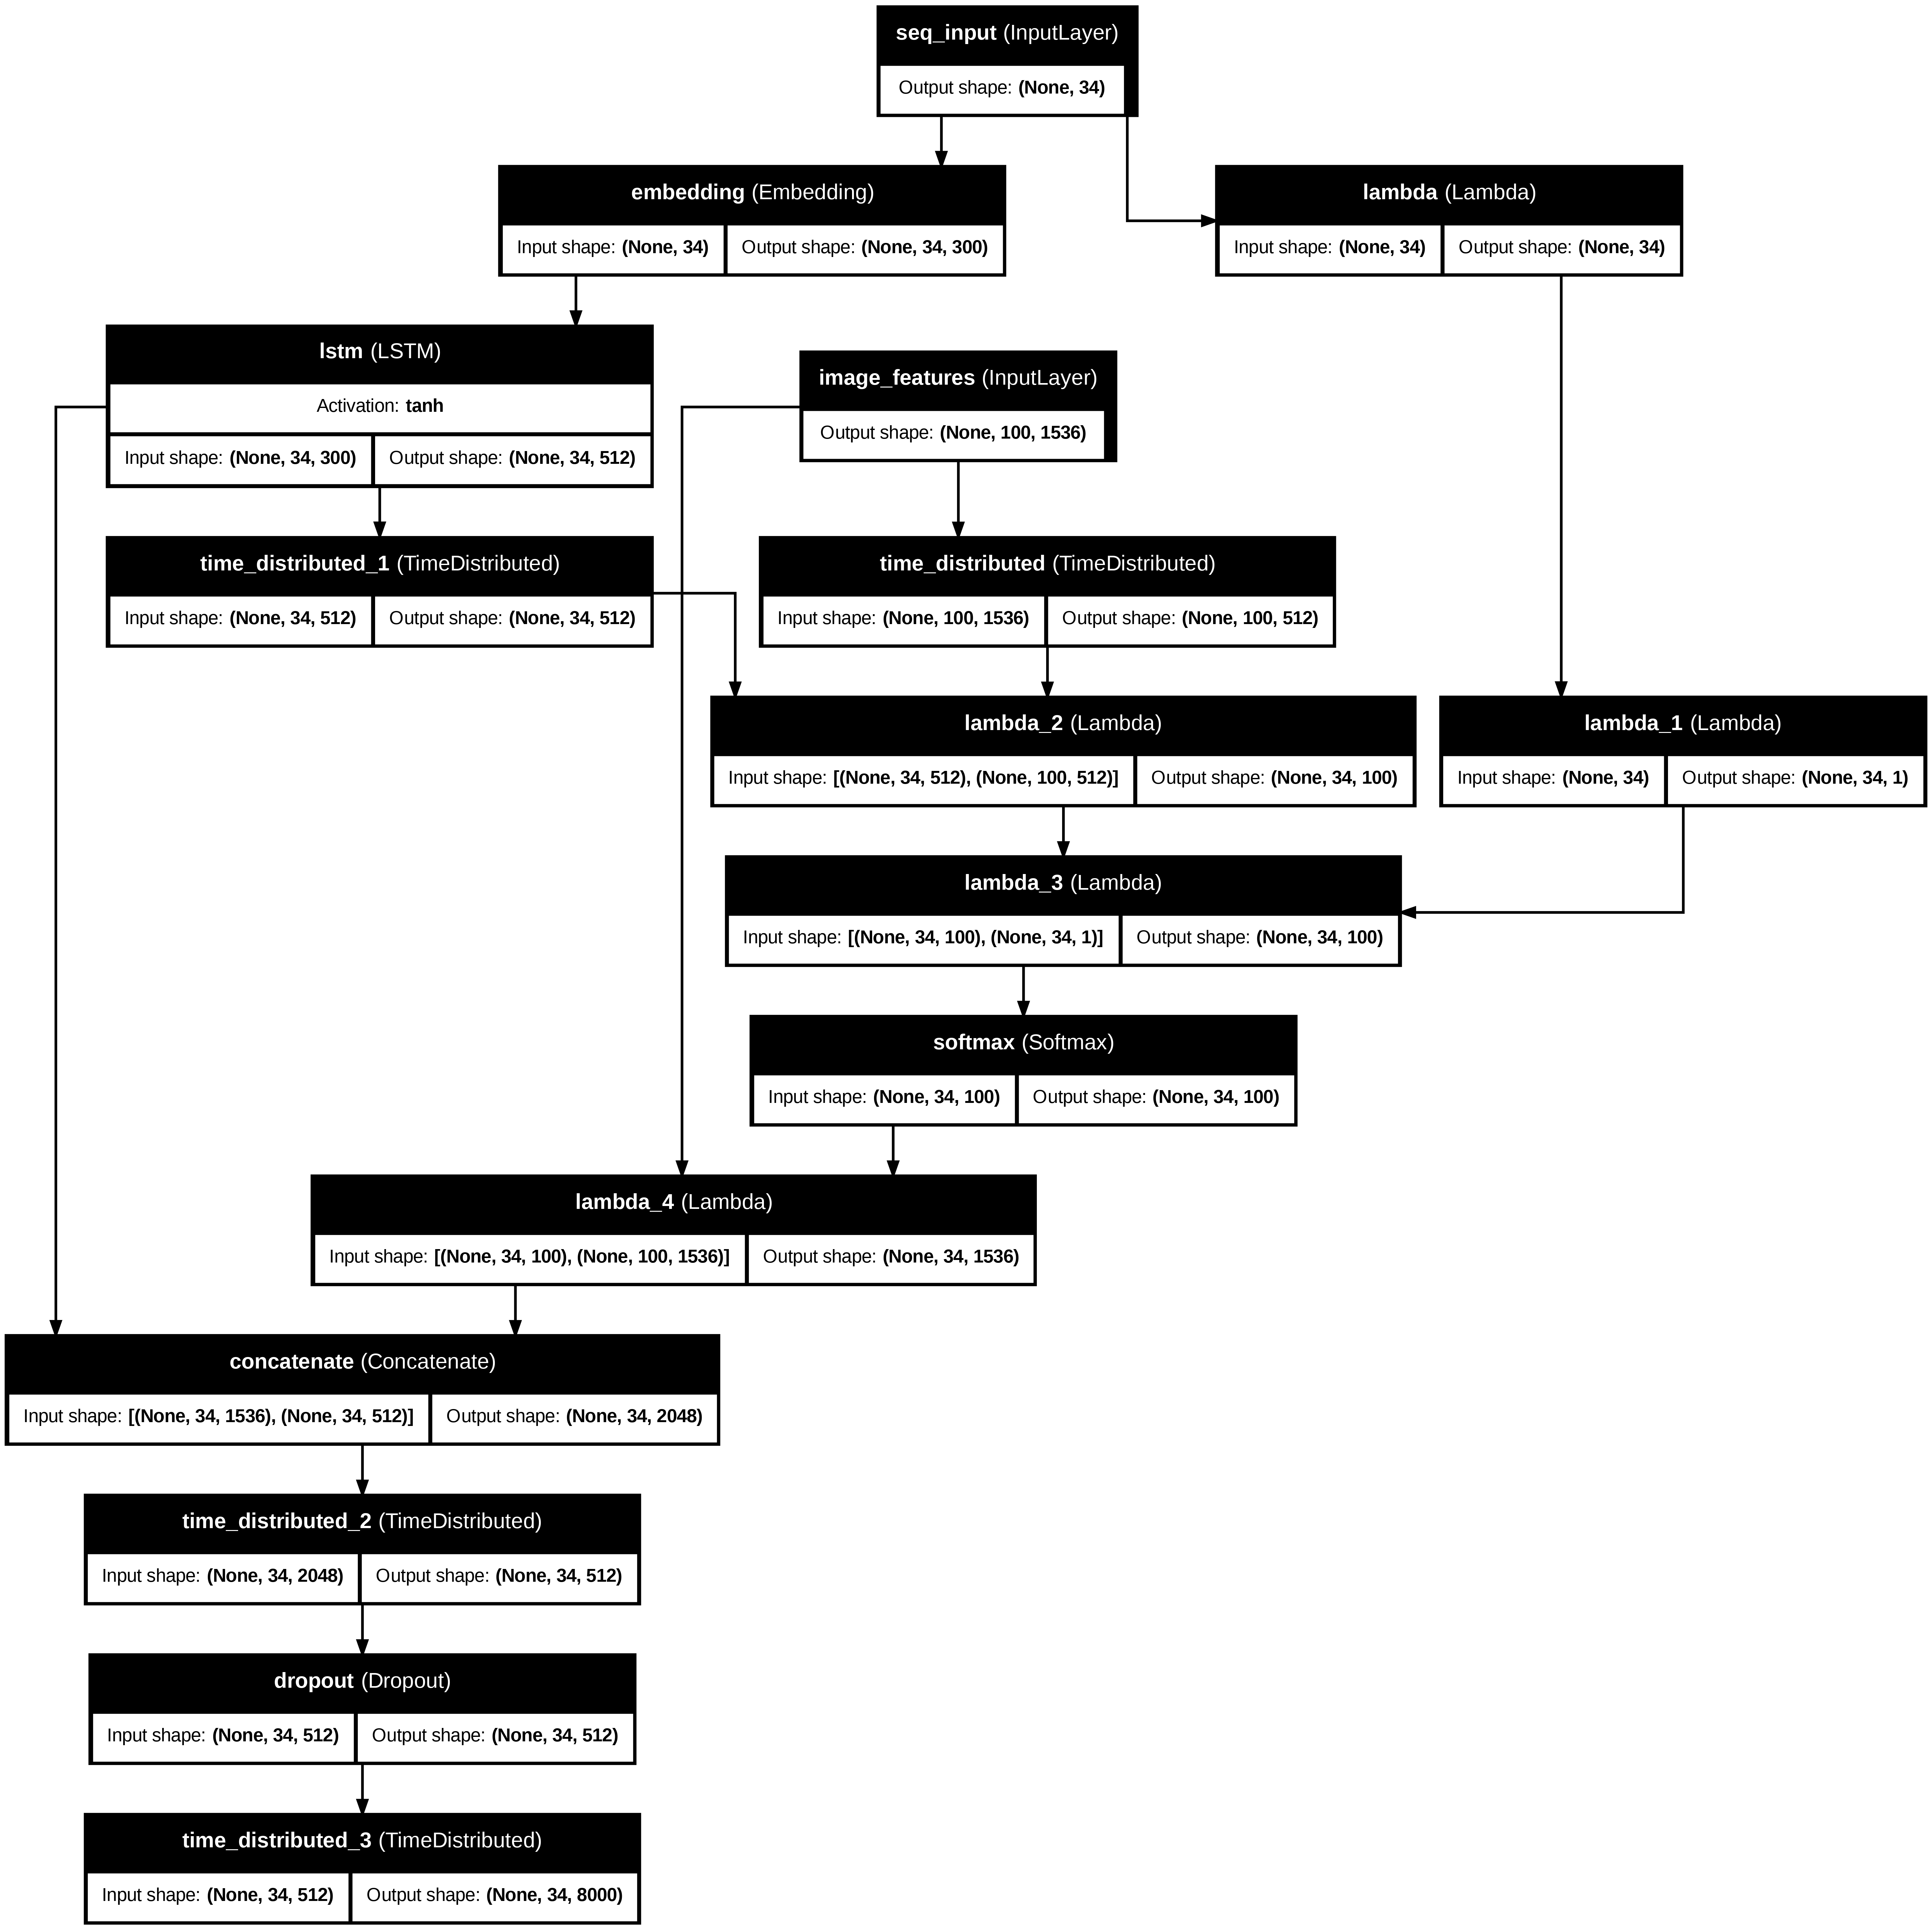

In [ ]:
from keras.utils import plot_model
plot_model(model, dpi=300, to_file='/content/drive/MyDrive/POM/ENBL_model.png', show_shapes=True, show_layer_names=True, expand_nested=True, show_layer_activations=True)

In [ ]:
print("Starting training...")
history = model.fit(train_gen,
                    validation_data=val_gen,
                    epochs=100,
                    initial_epoch=50,
                    callbacks=[cb_checkpoint, cb_csv, cb_tqdm],
                    verbose=1)  # keep verbose for Keras progress bar

# Save final model weights and tokenizer
# final_weights = os.path.join(CHECKPOINT_DIR, "weights.keras")
# model.save_weights(final_weights)
# print("Saved final weights to:", final_weights)

# Save tokenizer vocabulary and config
with open(os.path.join(CHECKPOINT_DIR, "tokenizer.json"), "w", encoding="utf-8") as f:
    f.write(tokenizer.to_json())

Starting training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 51/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.8383 - sparse_categorical_accuracy: 0.8209
Epoch 51: val_loss improved from inf to 0.80411, saving model to /content/drive/MyDrive/POM/model_checkpoint.keras
Epoch 51: loss=0.8424, acc=0.8196, val_loss=0.8041, val_acc=0.8249
114/114 ━━━━━━━━━━━━━━━━━━━━ 34s 175ms/step - loss: 0.8383 - sparse_categorical_accuracy: 0.8208 - val_loss: 0.8041 - val_sparse_categorical_accuracy: 0.8249
Epoch 52/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.8405 - sparse_categorical_accuracy: 0.8195
Epoch 52: val_loss improved from 0.80411 to 0.79861, saving model to /content/drive/MyDrive/POM/model_checkpoint.keras
Epoch 52: loss=0.8384, acc=0.8200, val_loss=0.7986, val_acc=0.8272
114/114 ━━━━━━━━━━━━━━━━━━━━ 19s 163ms/step - loss: 0.8405 - sparse_categorical_accuracy: 0.8196 - val_loss: 0.7986 - val_sparse_categorical_accuracy: 0.8272
Epoch 53/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.8223 - sparse_categorical_accura

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot(csv_file, filename):
    # Read the CSV file
    df = pd.read_csv(csv_file)

    acc = df['sparse_categorical_accuracy'].values
    val_acc = df['val_sparse_categorical_accuracy'].values
    loss = df['loss'].values
    val_loss = df['val_loss'].values  # Using wdl_loss as validation loss

    # Create the subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle("ENBL MODEL METRICS VISUALIZATION", fontsize=16, fontweight='bold')

    # Get epoch numbers from your data
    epochs = df['epoch'].values

    # Plot 1: Accuracy
    ax1.plot(epochs, acc, markersize=3, linewidth=2)
    ax1.plot(epochs, val_acc, markersize=3, linewidth=2)
    ax1.set_title('History of Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend(['training', 'validation'])
    ax1.grid(True, alpha=0.3)

    # Plot 2: Loss
    ax2.plot(epochs, loss, markersize=3, linewidth=2)
    ax2.plot(epochs, val_loss, markersize=3, linewidth=2)
    ax2.set_title('History of Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend(['training', 'validation'])
    ax2.grid(True, alpha=0.3)

    # # Plot 3: Precision
    # ax3.plot(epochs, precision, marker='o', markersize=3, linewidth=2)
    # ax3.plot(epochs, val_precision, marker='s', markersize=3, linewidth=2)
    # ax3.set_title('History of Precision')
    # ax3.set_xlabel('Epochs')
    # ax3.set_ylabel('Precision')
    # ax3.legend(['training', 'validation'])
    # ax3.grid(True, alpha=0.3)

    # # Plot 4: Recall
    # ax4.plot(epochs, recall, marker='o', markersize=3, linewidth=2)
    # ax4.plot(epochs, val_recall, marker='s', markersize=3, linewidth=2)
    # ax4.set_title('History of Recall')
    # ax4.set_xlabel('Epochs')
    # ax4.set_ylabel('Recall')
    # ax4.legend(['training', 'validation'])
    # ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

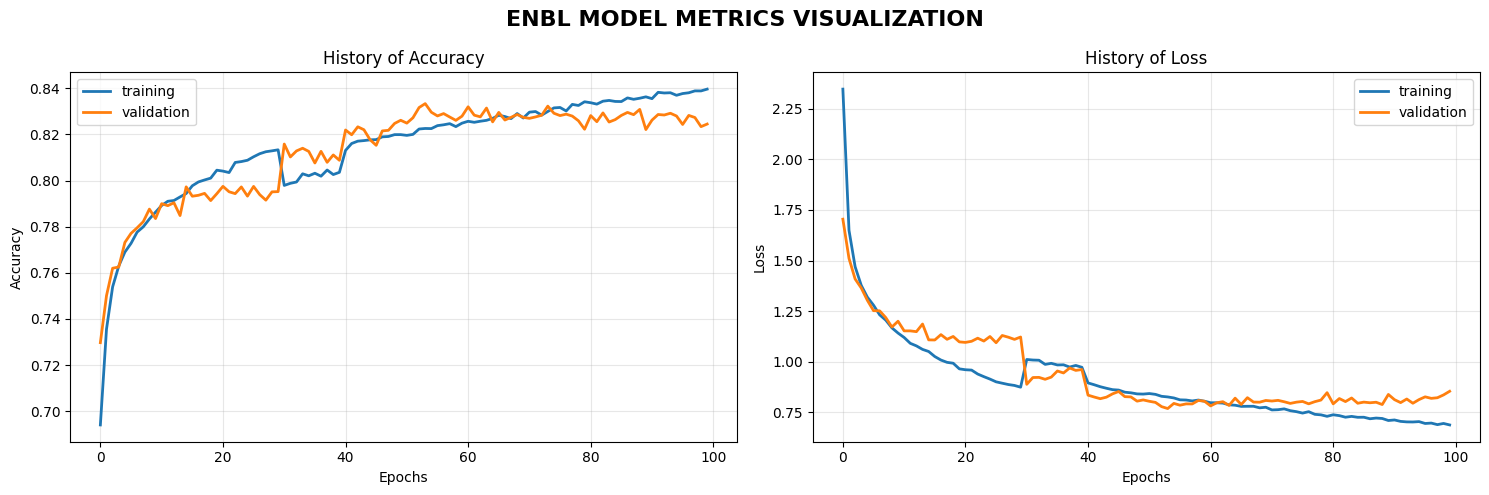

In [ ]:
csv_file = '/content/drive/MyDrive/POM/training_log.csv'
output_filename = '/content/drive/MyDrive/POM/ENBL_model_metrics.png'
plot(csv_file, output_filename)

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tensorflow.keras.preprocessing.text import tokenizer_from_json
import os

nltk.download('punkt') # Required for some tokenization methods if not already downloaded

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

First, let's load the tokenizer and the trained model. We'll need to rebuild the model architecture and then load the saved weights.

In [ ]:
for img_name in tqdm(all_images_temp, desc="Loading features for model def"):
    all_image_features[img_name] = load_image_feature_by_name(img_name, FEATURES_DIR)
    print("All image features loaded for model definition.")

In [31]:
# # Load the tokenizer
with open(os.path.join("/content/drive/MyDrive/Image Caption Generator", "tokenizer.json"), "r", encoding="utf-8") as f:
    json_string = f.read() # Read the raw JSON string content
    loaded_tokenizer = tokenizer_from_json(json_string) # Pass the JSON string to the function

# Re-initialize necessary variables (if they went out of scope)
# These should be available from previous `main()` run, but for robustness:
if 'vocab_size' not in locals():
    img_to_caps_temp, _, vocab_size = prepare_data_and_tokenizer() # Ensure img_to_caps_temp is available here

if 'num_patches' not in locals() or 'feat_dim' not in locals():
    # Need to load all image features into memory for the `sample_feat` to get shape info
    if 'all_image_features' not in locals():
        print("Loading all image features into memory for model definition...")
        # Use img_to_caps_temp if vocab_size was just re-initialized, otherwise ensure img_to_caps is available
        if 'img_to_caps' not in locals():
            img_to_caps, _, _ = prepare_data_and_tokenizer() # Re-load img_to_caps if needed
        all_images_temp = list(img_to_caps.keys())
        all_image_features = {}
        for img_name in tqdm(all_images_temp, desc="Loading features for model def"):
            all_image_features[img_name] = load_image_feature_by_name(img_name, FEATURES_DIR)
        print("All image features loaded for model definition.")

    sample_feat = all_image_features[list(all_image_features.keys())[0]] # Get first image's features
    num_patches, feat_dim = sample_feat.shape
    print(f"Feature patch count: {num_patches}, feature dim: {feat_dim}")

# Build the model architecture
model = build_caption_model(num_patches=num_patches, feat_dim=feat_dim,
                            vocab_size=vocab_size, max_len=MAX_LEN,
                            embed_dim=EMBED_DIM, lstm_units=LSTM_UNITS, attn_units=ATTN_UNITS)

# Load the best weights
if os.path.exists(BEST_MODEL_PATH):
    try:
        print(f"Loading model weights from: {BEST_MODEL_PATH}")
        model.load_weights(BEST_MODEL_PATH)
    except Exception as e:
        print(f"Error loading model weights: {e}")
else:
    print(f"Model checkpoint not found at {BEST_MODEL_PATH}. Cannot evaluate without trained weights.")

Model checkpoint not found at /content/drive/MyDrive/Image Caption Generator/model_checkpoint.keras. Cannot evaluate without trained weights.


In [32]:
model.load_weights("/content/drive/MyDrive/Image Caption Generator/model.keras")

In [33]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 34, 300)   │  2,400,000 │ seq_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 34, 512)   │  1,665,024 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 100, 1536) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 34, 512)   │    262,656 │ lstm_1[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 100, 512)  │    786,944 │ image_features[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 34)        │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 34, 100)   │          0 │ time_distributed… │
│                     │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 34, 1)     │          0 │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_8 (Lambda)   │ (None, 34, 100)   │          0 │ lambda_7[0][0],   │
│                     │                   │            │ lambda_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_1 (Softmax) │ (None, 34, 100)   │          0 │ lambda_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 34, 1536)  │          0 │ softmax_1[0][0],  │
│                     │                   │            │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 34, 2048)  │          0 │ lambda_9[0][0],   │
│ (Concatenate)       │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 34, 512)   │  1,049,088 │ concatenate_1[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 34, 512)   │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_7  │ (None, 34, 8000)  │  4,104,000 │ dropout_1[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,267,712 (39.17 MB)

 Trainable params: 10,267,712 (39.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import os
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

def load_feature(img_name):
    return img_name, np.load(os.path.join(FEATURES_DIR, img_name + ".npz"))

all_images = list(img_to_caps.keys())

print("Loading features into memory (fast mode)...")

all_image_features = {}
with ThreadPoolExecutor(max_workers=16) as executor:
    for img_name, feat in tqdm(
        executor.map(load_feature, all_images),
        total=len(all_images),
        desc="Loading features"
    ):
        all_image_features[img_name] = feat

print("Done. Features fully in RAM.")


Loading features into memory (fast mode)...


Loading features: 100%|██████████| 8091/8091 [03:27<00:00, 38.97it/s]

Done. Features fully in RAM.


In [36]:
def generate_caption(model, feature_extractor, image_name, tokenizer, max_len, all_image_features):
    # Load image features from the pre-loaded dictionary
    image_features = all_image_features[image_name]
    # Expand dimensions to create a batch size of 1
    image_features = np.expand_dims(image_features, axis=0) # (1, num_patches, feat_dim)

    # Start the caption with 'startseq'
    in_text = 'startseq'
    for i in range(max_len):
        # Encode the input text sequence
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        # Pad the sequence to max_len
        sequence = pad_sequences([sequence], maxlen=max_len, padding='post')[0]
        sequence = np.expand_dims(sequence, axis=0) # (1, max_len)

        # Predict the next word
        yhat = model.predict([image_features, sequence], verbose=0)
        # Get the index of the word with the highest probability
        yhat_word_idx = np.argmax(yhat[0, i, :]) # Take prediction for the current timestep (i)

        # Map the index to a word
        word = tokenizer.index_word.get(yhat_word_idx, None)

        # Break if word is not found or is the end sequence token
        if word is None or word == 'endseq':
            break

        # Append the predicted word to the input text
        in_text += ' ' + word

    final_caption = in_text.replace('startseq ', '') # Remove the 'startseq' token
    return final_caption

In [ ]:
# Prepare data for BLEU score calculation
# Ensure `img_to_caps` and `val_images` are available
if 'img_to_caps' not in locals():
    img_to_caps, _, _ = prepare_data_and_tokenizer()

if 'val_images' not in locals():
    all_images_temp = list(img_to_caps.keys())
    random.shuffle(all_images_temp)
    split = int(len(all_images_temp) * TRAIN_VAL_SPLIT)
    val_images = all_images_temp[split:]

# Ensure all_image_features is loaded as it's needed by generate_caption
if 'all_image_features' not in locals():
    print("Loading all image features into memory for caption generation...")
    all_images_temp = list(img_to_caps.keys())
    all_image_features = {}
    for img_name in tqdm(all_images_temp, desc="Loading features for caption gen"):
        all_image_features[img_name] = load_image_feature_by_name(img_name, FEATURES_DIR)
    print("All image features loaded for caption generation.")

# Assuming `fe` (feature_extractor) is available from `main` or rebuild it if needed
if 'fe' not in locals():
    fe = build_feature_extractor()

bleu1_scores = []
bleu2_scores = []
bleu3_scores = []
bleu4_scores = []

smoothie = SmoothingFunction().method4 # Use smoothing for BLEU scores

print("Generating captions and calculating BLEU scores for validation set...")
for img_name in tqdm(val_images, desc="Evaluating BLEU scores"):
    reference_captions = [cap.replace('startseq ', '').replace(' endseq', '').split() for cap in img_to_caps[img_name]]
    generated_caption = generate_caption(model, fe, img_name, loaded_tokenizer, MAX_LEN, all_image_features)
    candidate_caption = generated_caption.split()

    if len(reference_captions) > 0 and len(candidate_caption) > 0:
        try:
            score1 = sentence_bleu(reference_captions, candidate_caption, weights=(1, 0, 0, 0), smoothing_function=smoothie)
            score2 = sentence_bleu(reference_captions, candidate_caption, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
            score3 = sentence_bleu(reference_captions, candidate_caption, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothie)
            score4 = sentence_bleu(reference_captions, candidate_caption, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
            bleu1_scores.append(score1)
            bleu2_scores.append(score2)
            bleu3_scores.append(score3)
            bleu4_scores.append(score4)
        except ZeroDivisionError:
            print(f"Warning: ZeroDivisionError for image {img_name}. Skipping BLEU calculation for this image.")

print("BLEU score calculation complete.")
print(f"Average BLEU-1: {np.mean(bleu1_scores):.4f}")
print(f"Average BLEU-2: {np.mean(bleu2_scores):.4f}")
print(f"Average BLEU-3: {np.mean(bleu3_scores):.4f}")
print(f"Average BLEU-4: {np.mean(bleu4_scores):.4f}")

Generating captions and calculating BLEU scores for validation set...


Evaluating BLEU scores: 100%|██████████| 810/810 [12:39<00:00,  1.07it/s]

BLEU score calculation complete.
Average BLEU-1: 0.6698
Average BLEU-2: 0.5139
Average BLEU-3: 0.3862
Average BLEU-4: 0.2863


Finally, let's plot the histograms for each BLEU score to visualize their distributions.

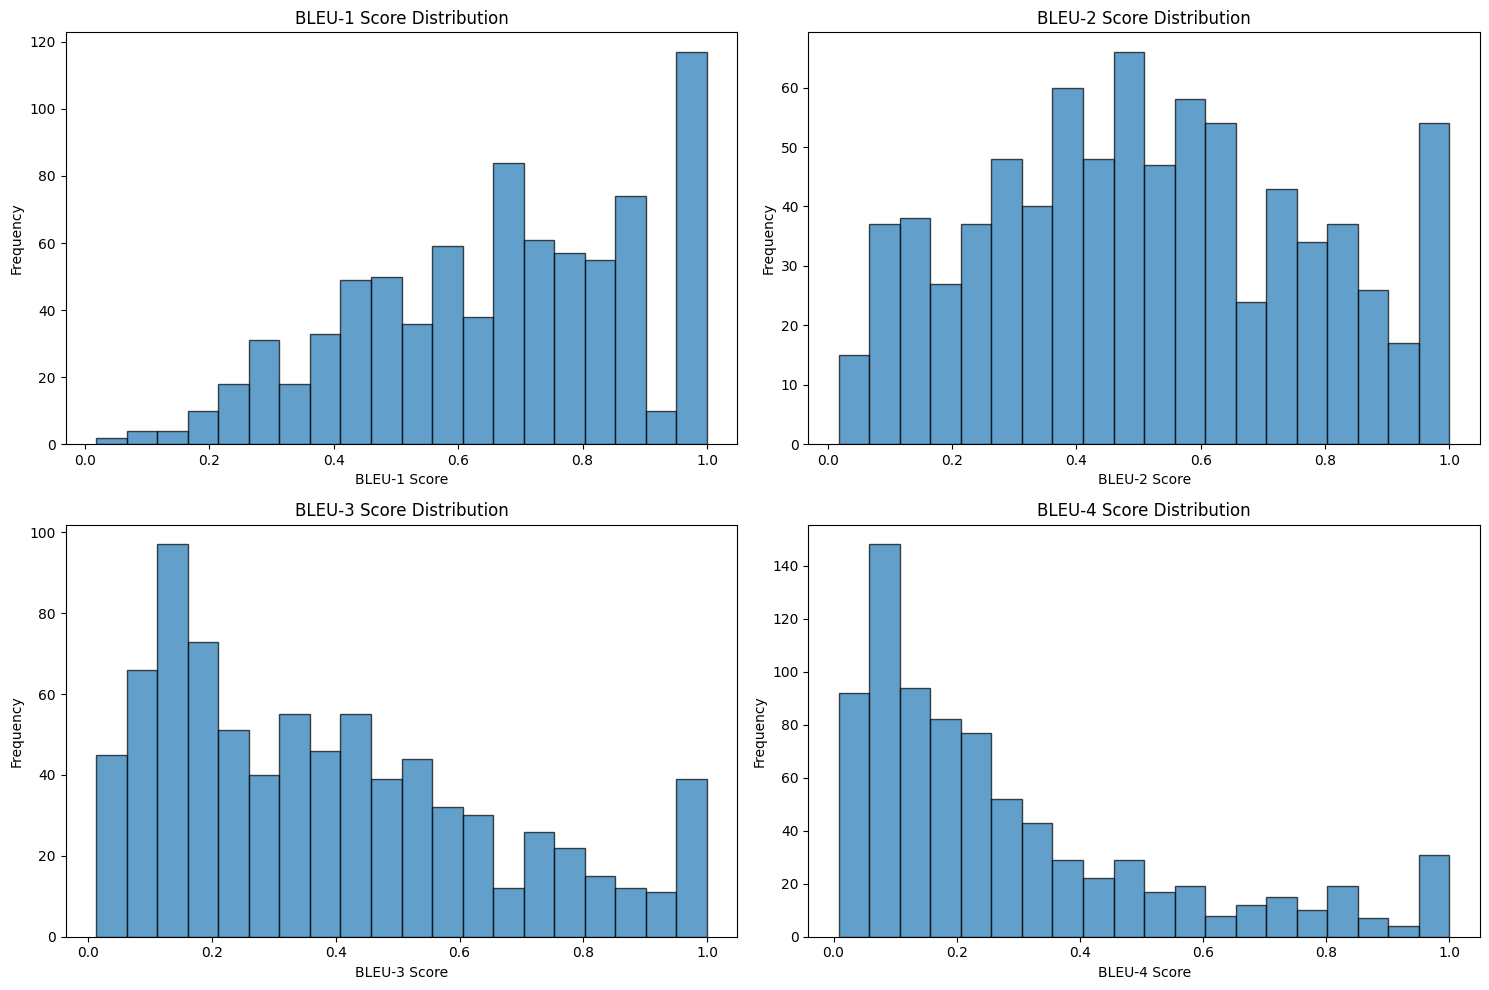

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.hist(bleu1_scores, bins=20, edgecolor='black', alpha=0.7)
plt.title('BLEU-1 Score Distribution')
plt.xlabel('BLEU-1 Score')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
plt.hist(bleu2_scores, bins=20, edgecolor='black', alpha=0.7)
plt.title('BLEU-2 Score Distribution')
plt.xlabel('BLEU-2 Score')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
plt.hist(bleu3_scores, bins=20, edgecolor='black', alpha=0.7)
plt.title('BLEU-3 Score Distribution')
plt.xlabel('BLEU-3 Score')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
plt.hist(bleu4_scores, bins=20, edgecolor='black', alpha=0.7)
plt.title('BLEU-4 Score Distribution')
plt.xlabel('BLEU-4 Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
img_to_caps, tokenizer, vocab_size = prepare_data_and_tokenizer()

# List of image filenames (keys in img_to_caps)
all_images = list(img_to_caps.keys())
random.shuffle(all_images)
split = int(len(all_images) * TRAIN_VAL_SPLIT)
train_images = all_images[:split]
val_images = all_images[split:]
print(f"Train images: {len(train_images)}, Val images: {len(val_images)}")

Vocabulary size: 8000, total images: 8091
Train images: 7281, Val images: 810


In [34]:
def compute_clip_score(val_images, IMAGES_DIR, model, tokenizer, max_len, all_image_features):
    scores = []

    with torch.no_grad():
        for img_name in tqdm(val_images, desc="Computing CLIPScore"):
            image_path = os.path.join(IMAGES_DIR, img_name)

            # Load image
            image = clip_preprocess(
                Image.open(image_path).convert("RGB")
            ).unsqueeze(0).to(device)

            # Generate caption
            caption = generate_caption(
                model, None, img_name, tokenizer, max_len, all_image_features
            )

            # Encode
            image_features = clip_model.encode_image(image)
            text_features = clip_model.encode_text(
                clip.tokenize([caption]).to(device)
            )

            # Normalize
            image_features /= image_features.norm(dim=-1, keepdim=True)
            text_features /= text_features.norm(dim=-1, keepdim=True)

            # Cosine similarity
            score = (image_features @ text_features.T).item()
            scores.append(score)

    return np.mean(scores), scores


In [41]:
avg_clip, clip_scores = compute_clip_score(
    val_images,
    IMAGES_DIR,
    model,
    tokenizer,
    MAX_LEN,
    all_image_features
)

print(f"Average CLIPScore: {avg_clip:.4f}")


Computing CLIPScore: 100%|██████████| 810/810 [14:04<00:00,  1.04s/it]

Average CLIPScore: 0.2785


In [38]:
print("Model object:", model)
print("Model type:", type(model))
print(model.summary())


Model object: <Functional name=functional_2, built=True>
Model type: <class 'keras.src.models.functional.Functional'>


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 34, 300)   │  2,400,000 │ seq_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 34, 512)   │  1,665,024 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 100, 1536) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 34, 512)   │    262,656 │ lstm_1[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 100, 512)  │    786,944 │ image_features[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 34)        │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 34, 100)   │          0 │ time_distributed… │
│                     │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 34, 1)     │          0 │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_8 (Lambda)   │ (None, 34, 100)   │          0 │ lambda_7[0][0],   │
│                     │                   │            │ lambda_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_1 (Softmax) │ (None, 34, 100)   │          0 │ lambda_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 34, 1536)  │          0 │ softmax_1[0][0],  │
│                     │                   │            │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 34, 2048)  │          0 │ lambda_9[0][0],   │
│ (Concatenate)       │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 34, 512)   │  1,049,088 │ concatenate_1[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 34, 512)   │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_7  │ (None, 34, 8000)  │  4,104,000 │ dropout_1[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,267,712 (39.17 MB)

 Trainable params: 10,267,712 (39.17 MB)

 Non-trainable params: 0 (0.00 B)

None


In [39]:
def prepare_cider_data(val_images, img_to_caps, model, tokenizer, max_len, all_image_features):
    gts = {}
    res = {}

    for idx, img_name in enumerate(val_images):
        # Ground truth captions
        references = []
        for cap in img_to_caps[img_name]:
            clean_cap = cap.replace("startseq ", "").replace(" endseq", "")
            references.append({"caption": clean_cap})

        gts[idx] = references

        # Generated caption
        generated = generate_caption(
            model, None, img_name, tokenizer, max_len, all_image_features
        )
        res[idx] = [{"caption": generated}]

    return gts, res


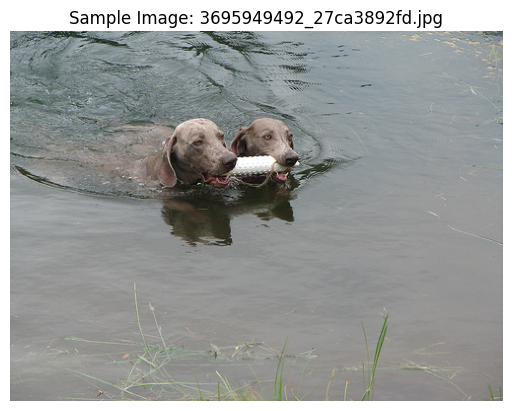


Ground Truth Captions for 3695949492_27ca3892fd.jpg:
1. dogs holding opposite ends of a toy with their mouths swimming
2. grey dogs are carrying a stick in the water
3. grey dogs swimming in a lake to retrieve a white toy
4. identical brown dogs side by side holding something white in both their mouths
5. similar brown dogs share holding a white toy while swimming


In [ ]:
import random
import matplotlib.pyplot as plt

# Select a random image from the validation set
sample_image_name = random.choice(val_images)

# Construct the full path to the image
sample_image_path = os.path.join(IMAGES_DIR, sample_image_name)

# Retrieve ground truth captions for the selected image
ground_truth_captions = img_to_caps[sample_image_name]

# Load and display the image
img = plt.imread(sample_image_path)
plt.imshow(img)
plt.axis('off') # Hide axes
plt.title(f"Sample Image: {sample_image_name}")
plt.show()

print(f"\nGround Truth Captions for {sample_image_name}:")
for i, caption in enumerate(ground_truth_captions):
    # Remove 'startseq' and 'endseq' for display clarity
    cleaned_caption = caption.replace('startseq ', '').replace(' endseq', '')
    print(f"{i+1}. {cleaned_caption}")

In [ ]:
def build_caption_model_with_attention(num_patches, feat_dim, vocab_size, max_len, embed_dim=EMBED_DIM,
                        lstm_units=LSTM_UNITS, attn_units=ATTN_UNITS):
    # Inputs
    img_feats_input = Input(shape=(num_patches, feat_dim), name="image_features")  # (batch, P, C)
    seq_input = Input(shape=(max_len,), name="seq_input")  # tokenized input sequence (post padding)

    # Project image features to a lower-dim space for attention
    img_feat_proj = layers.TimeDistributed(layers.Dense(attn_units, activation="tanh"))(img_feats_input)  # (batch, P, A)

    # sequence embedding + initial LSTM that returns sequences
    emb = layers.Embedding(vocab_size, embed_dim, mask_zero=False)(seq_input)  # (batch, T, E)
    decoder_seq = layers.LSTM(lstm_units, return_sequences=True)(emb)  # (batch, T, U)

    # Build a padding mask directly from seq_input (KerasTensor-safe)
    # mask_bool: (batch, T) boolean; then cast to float32 and expand -> (batch, T, 1)
    mask_float = layers.Lambda(lambda x: tf.cast(tf.not_equal(x, 0), tf.float32))(seq_input)
    mask_float = layers.Lambda(lambda m: tf.expand_dims(m, axis=-1))(mask_float)  # (batch, T, 1)

    # project decoder hidden states to attn_units
    dec_proj = layers.TimeDistributed(layers.Dense(attn_units, activation="tanh"))(decoder_seq)  # (batch, T, A)

    # Compute scores: batch matmul between dec_proj and img_feat_proj^T
    # dec_proj: (batch, T, A); img_feat_proj: (batch, P, A)
    # scores: (batch, T, P)
    # Use tf.einsum for batch matrix multiplication to avoid ValueError with KerasTensors in TF functions.
    scores = layers.Lambda(lambda x: tf.einsum('bta,bpa->btp', x[0], x[1]))([dec_proj, img_feat_proj])

    # Apply mask to scores: expand mask to match scores shape for broadcasting
    # mask_float currently (batch, T, 1) -> broadcast to (batch, T, P) automatically when used in arithmetic
    large_neg = tf.constant(-1e9, dtype=tf.float32)
    masked_scores = layers.Lambda(lambda x: x[0] + (1.0 - x[1]) * large_neg)([scores, mask_float])

    # Softmax over patch dimension (P)
    attn_weights = layers.Softmax(axis=-1)(masked_scores)  # (batch, T, P)

    # Context vector: weighted sum of original image features (not projected) -> (batch, T, feat_dim)
    context = layers.Lambda(lambda x: tf.matmul(x[0], x[1]))([attn_weights, img_feats_input])  # (batch, T, C)

    # Combine context with decoder_seq (concatenate) and pass through TimeDistributed dense -> logits per timestep
    combined = layers.Concatenate(axis=-1)([context, decoder_seq])  # (batch, T, C+U)
    combined = layers.TimeDistributed(layers.Dense(512, activation="relu"))(combined)
    combined = layers.Dropout(0.25)(combined)
    outputs = layers.TimeDistributed(layers.Dense(vocab_size, activation="softmax"))(combined)  # (batch, T, V)

    model = Model(inputs=[img_feats_input, seq_input], outputs=[outputs, attn_weights])
    return model

# Instantiate the new model
print("Building attention-enhanced model...")
model_with_attention = build_caption_model_with_attention(num_patches=num_patches, feat_dim=feat_dim,
                                                        vocab_size=vocab_size, max_len=MAX_LEN,
                                                        embed_dim=EMBED_DIM, lstm_units=LSTM_UNITS, attn_units=ATTN_UNITS)

# Load the best weights into the new model
if os.path.exists(BEST_MODEL_PATH):
    try:
        print(f"Loading trained weights from: {BEST_MODEL_PATH} into attention-enhanced model...")
        model_with_attention.load_weights(BEST_MODEL_PATH)
        print("Weights loaded successfully.")
    except Exception as e:
        print(f"Error loading model weights into attention-enhanced model: {e}")
else:
    print(f"Model checkpoint not found at {BEST_MODEL_PATH}. Cannot load trained weights for attention-enhanced model.")

Building attention-enhanced model...
Loading trained weights from: /content/drive/MyDrive/POM/model_checkpoint.keras into attention-enhanced model...
Weights loaded successfully.


In [ ]:
def generate_caption_and_attention(model_with_attention, image_name, tokenizer, max_len, all_image_features):
    """
    Generates a caption for an image and captures attention weights for each generated word.

    Args:
        model_with_attention: The Keras model that outputs both word probabilities and attention weights.
        image_name (str): The filename of the image.
        tokenizer: The Keras Tokenizer object.
        max_len (int): The maximum length of the caption.
        all_image_features (dict): A dictionary containing pre-extracted image features.

    Returns:
        tuple: A tuple containing the generated caption (str) and a list of attention weights (np.array).
    """
    # 1. Retrieve image features
    image_features = all_image_features[image_name]
    # Expand dimensions to create a batch size of 1
    image_features = np.expand_dims(image_features, axis=0) # (1, num_patches, feat_dim)

    # 2. Initialize input text and attention weights storage
    in_text = 'startseq'
    attention_weights_list = []

    # 3. Loop to generate caption word by word
    for i in range(max_len):
        # a. Convert current input text sequence to numerical tokens
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        # b. Pad the sequence to max_len
        sequence_padded = pad_sequences([sequence], maxlen=max_len, padding='post')[0]
        # c. Expand dimensions to form a batch of size 1
        sequence_padded = np.expand_dims(sequence_padded, axis=0) # (1, max_len)

        # d. Predict the next word and attention weights
        yhat_preds, attn_weights_all_timesteps = model_with_attention.predict([image_features, sequence_padded], verbose=0)

        predicted_word_probs = yhat_preds[0, len(sequence)-1, :]
        yhat_word_idx = np.argmax(predicted_word_probs)

        # f. Map the index to a word
        word = tokenizer.index_word.get(yhat_word_idx, None)

        # g. Break if word is not found or is the end sequence token
        if word is None or word == 'endseq':
            break

        # h. Append the predicted word to the input text
        in_text += ' ' + word

        # i. Store the attention weights corresponding to the current generated word
        current_attn_weights = attn_weights_all_timesteps[0, len(sequence)-1, :]
        attention_weights_list.append(current_attn_weights)

    # Clean the generated caption by removing the 'startseq' token
    final_caption = in_text.replace('startseq ', '')
    return final_caption, attention_weights_list

In [ ]:
predicted_caption, attention_weights_per_word = generate_caption_and_attention(model_with_attention, sample_image_name, loaded_tokenizer, MAX_LEN, all_image_features)

print(f"Generated Caption for {sample_image_name}: {predicted_caption}")
print(f"Number of words in generated caption: {len(predicted_caption.split())}")
print(f"Number of attention weight sets: {len(attention_weights_per_word)}")


Generated Caption for 3695949492_27ca3892fd.jpg: brown dog is swimming in the water
Number of words in generated caption: 7
Number of attention weight sets: 7


In [ ]:
if 'val_images' not in locals():
    img_to_caps_temp, _, _ = prepare_data_and_tokenizer()
    all_images_temp = list(img_to_caps_temp.keys())
    random.shuffle(all_images_temp)
    split = int(len(all_images_temp) * TRAIN_VAL_SPLIT)
    val_images = all_images_temp[split:]
    img_to_caps = img_to_caps_temp # Ensure img_to_caps is available

Vocabulary size: 8000, total images: 8091


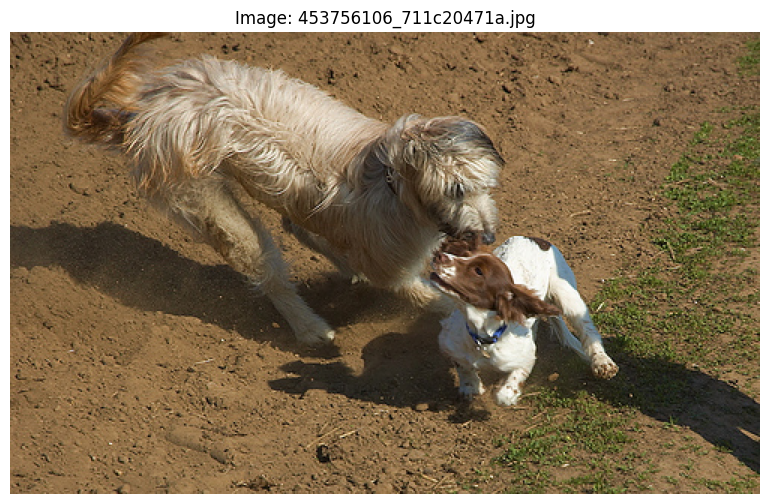


Generated Caption: dog is running in the dirt
Reference Captions:
  1. large brown fluffy dog with a small white and brown dog on a dirt surface
  2. large dog is playing with a small dog in the dirt
  3. small dog and a large dog play together
  4. playing with little dog in dirt
  5. dogs play with each other in the dirt

--------------------------------------------------



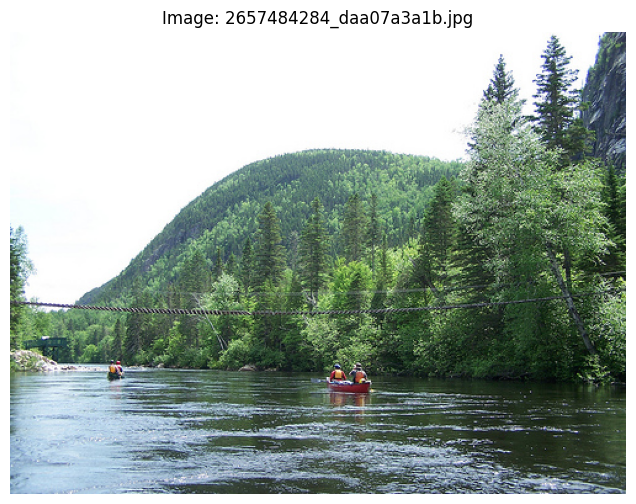


Generated Caption: people are in a river
Reference Captions:
  1. kayak on the river is passing by a wire bridge that joins both banks
  2. people ride their kayaks down the river
  3. conoes float down the river
  4. groups are canoeing on a river overlooking a mountain
  5. people rafting down a river a footbridge in the background

--------------------------------------------------



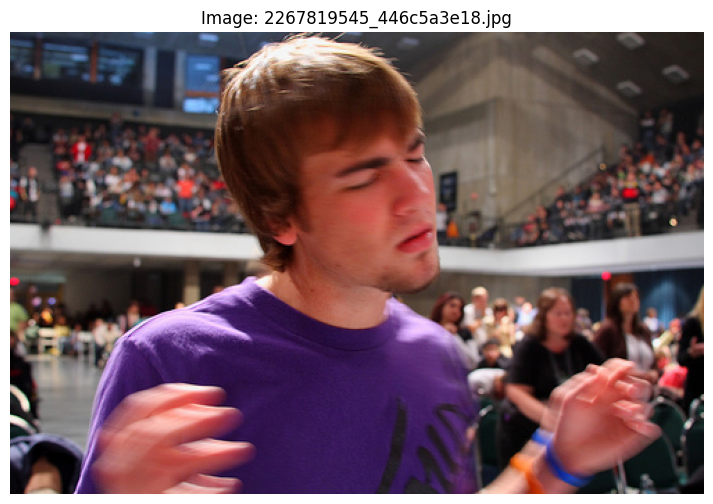


Generated Caption: woman in a blue shirt is standing in a crowd
Reference Captions:
  1. boy appears to be dancing to music in a building filled with people
  2. man consumed by his surroundings
  3. man in a purple shirt is standing in a stadium with his eyes closed
  4. man in a purple shirt is standing with his eyes closed
  5. young man with a beard at an event

--------------------------------------------------



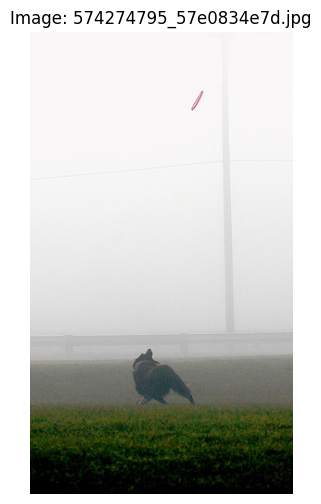


Generated Caption: dog is running through the field of a field
Reference Captions:
  1. black dog is poised to catch a frisbee
  2. brown dog runs after a red frisbee
  3. dog in the foggy distance catching a frisbee
  4. dog runs through grass while a frisbee flies through the air
  5. running after frisbee in field

--------------------------------------------------



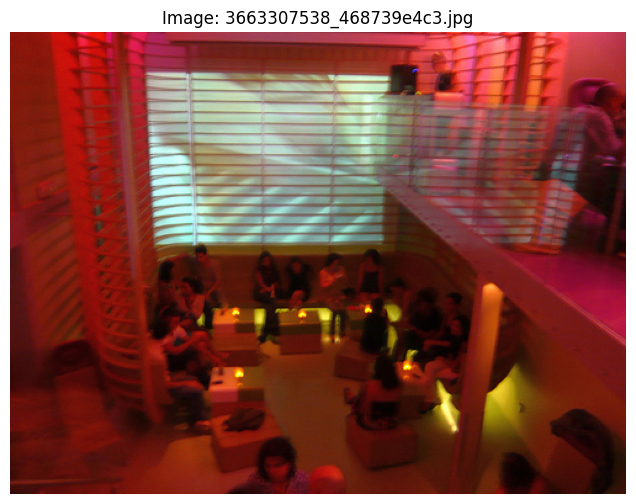


Generated Caption: group of people are sitting in a red room
Reference Captions:
  1. group of people sitting in a pink room with candles
  2. large group of people are sitting down inside a building with red and yellow lights everywhere
  3. are sitting at square tables in a red room
  4. in a dimly lit lounge
  5. people sitting at small tables in a darkened room

--------------------------------------------------



In [ ]:
import random
import matplotlib.pyplot as plt

# Ensure necessary variables are available from previous runs
if 'val_images' not in locals():
    img_to_caps_temp, _, _ = prepare_data_and_tokenizer()
    all_images_temp = list(img_to_caps_temp.keys())
    random.shuffle(all_images_temp)
    split = int(len(all_images_temp) * TRAIN_VAL_SPLIT)
    val_images = all_images_temp[split:]
    img_to_caps = img_to_caps_temp # Ensure img_to_caps is available

if 'loaded_tokenizer' not in locals():
    with open(os.path.join(CHECKPOINT_DIR, "tokenizer.json"), "r", encoding="utf-8") as f:
        json_string = f.read()
        loaded_tokenizer = tokenizer_from_json(json_string)

if 'all_image_features' not in locals():
    print("Loading all image features into memory for caption generation...")
    all_images_temp = list(img_to_caps.keys())
    all_image_features = {}
    for img_name in tqdm(all_images_temp, desc="Loading features for display"):
        all_image_features[img_name] = load_image_feature_by_name(img_name, FEATURES_DIR)
    print("All image features loaded for display.")

if 'model' not in locals():
    # Rebuild model architecture and load weights
    if 'num_patches' not in locals() or 'feat_dim' not in locals() or 'vocab_size' not in locals():
        # This part assumes num_patches, feat_dim, vocab_size are already set from earlier cells
        # If not, you might need to run the model building cells first or derive them.
        # For simplicity, we assume they are available after running up to model training.
        sample_feat = all_image_features[list(all_image_features.keys())[0]]
        num_patches, feat_dim = sample_feat.shape
        vocab_size = len(loaded_tokenizer.word_index) + 1

    model = build_caption_model(num_patches=num_patches, feat_dim=feat_dim,
                                vocab_size=vocab_size, max_len=MAX_LEN,
                                embed_dim=EMBED_DIM, lstm_units=LSTM_UNITS, attn_units=ATTN_UNITS)
    if os.path.exists(BEST_MODEL_PATH):
        try:
            model.load_weights(BEST_MODEL_PATH)
            print("Model weights loaded for display.")
        except Exception as e:
            print(f"Warning: could not load model weights for display: {e}")

# Select a few random images from the validation set for display
num_samples = 5 # You can change this number
sample_images_for_display = random.sample(val_images, num_samples)

for img_name in sample_images_for_display:
    image_path = os.path.join(IMAGES_DIR, img_name)

    # Display the image
    img = plt.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Image: {img_name}")
    plt.show()

    # Generate caption
    generated_caption = generate_caption(model, fe, img_name, loaded_tokenizer, MAX_LEN, all_image_features)
    print(f"\nGenerated Caption: {generated_caption}")

    # Print reference captions
    reference_captions = img_to_caps[img_name]
    print("Reference Captions:")
    for i, cap in enumerate(reference_captions):
        cleaned_cap = cap.replace('startseq ', '').replace(' endseq', '')
        print(f"  {i+1}. {cleaned_cap}")
    print("\n" + "-"*50 + "\n") # Separator